# PDF Drug Prediction Accuracy
**GT:** `pdf_active_drugs_per_visit.csv` — ground-truth active drug set per visit  
**Pred:** `pdf_pred_active_drugs_per_visit.csv` — 3 predicted options per visit (separated by `|`)  
**Match rule:** GT drug set == drug set from any of the 3 predicted options  
**Patients:** 372 PDF patients, up to 10 visits each

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, re

HERE = os.path.abspath('')
gt   = pd.read_csv(os.path.join(HERE, 'pdf_active_drugs_per_visit.csv'))
pred = pd.read_csv(os.path.join(HERE, 'pdf_pred_active_drugs_per_visit.csv'))

assert list(gt.pid) == list(pred.pid), 'pid mismatch'

# Detect all visit columns (v1..v10)
visit_cols = [c for c in gt.columns if re.match(r'^v\d+$', c)]
print(f'Patients: {len(gt)}, Visit columns: {visit_cols}')

def drug_set(cell):
    if pd.isna(cell) or str(cell).strip() == '':
        return frozenset()
    return frozenset(d.strip().lower() for d in str(cell).split(';') if d.strip())

# Build long-form df: one row per (patient, visit)
rows = []
for i in range(len(gt)):
    pid = gt.iloc[i]['pid']
    for vcol in visit_cols:
        vnum = int(vcol[1:])
        gt_cell = gt.iloc[i][vcol]
        pred_cell = pred.iloc[i][vcol]

        # NaN means this patient has no visit N
        if pd.isna(gt_cell) and pd.isna(pred_cell):
            continue

        gt_drugs = drug_set(gt_cell)
        pred_str = str(pred_cell) if pd.notna(pred_cell) else ''
        options = [drug_set(opt) for opt in pred_str.split('|')] if pred_str.strip() else []

        if not gt_drugs:
            match = False
            matched_k = None
            mono_poly = 'empty'
        else:
            match = any(gt_drugs == o for o in options)
            matched_k = next((k+1 for k, o in enumerate(options) if gt_drugs == o), None)
            mono_poly = 'mono' if len(gt_drugs) == 1 else 'poly'

        rows.append(dict(
            pid=pid, visit=vnum, mono_poly=mono_poly,
            gt='; '.join(sorted(gt_drugs)), gt_size=len(gt_drugs),
            match=match, matched_k=matched_k,
            opt1='; '.join(sorted(options[0])) if len(options) > 0 else '',
            opt2='; '.join(sorted(options[1])) if len(options) > 1 else '',
            opt3='; '.join(sorted(options[2])) if len(options) > 2 else '',
        ))

df = pd.DataFrame(rows)
print(f'Total rows (patient×visit): {len(df)}')
df.head(6)

Patients: 372, Visit columns: ['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10']
Total rows (patient×visit): 1486


,pid,visit,mono_poly,gt,gt_size,match,matched_k,opt1,opt2,opt3
0,AARON RODNEY MUKAGA,1,mono,levetiracetam,1,True,1.0,levetiracetam,carbamazepine,phenobarbital
1,AARON RODNEY MUKAGA,2,mono,levetiracetam,1,True,1.0,levetiracetam,carbamazepine,phenobarbital
2,AARON RODNEY MUKAGA,3,mono,levetiracetam,1,True,1.0,levetiracetam,carbamazepine,phenobarbital
3,AARON RODNEY MUKAGA,4,mono,levetiracetam,1,True,1.0,levetiracetam,carbamazepine,phenobarbital
4,AARON_OCHWO,1,mono,levetiracetam,1,False,NaN,valproate,carbamazepine,phenobarbital
5,AARON_OCHWO,2,mono,levetiracetam,1,True,1.0,levetiracetam,carbamazepine,clobazam; levetiracetam


---
## Overall Accuracy by Visit

 visit   n  correct   accuracy
     1 372      240  64.516129
     2 367      244  66.485014
     3 342      240  70.175439
     4 234      143  61.111111
     5 106       60  56.603774
     6  44       19  43.181818
     7  15        6  40.000000
     8   4        2  50.000000
     9   1        1 100.000000
    10   1        1 100.000000


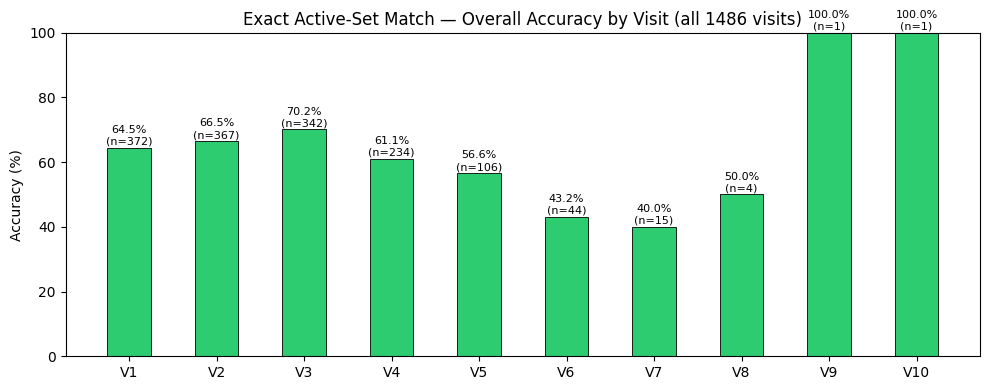


Overall (all visits): 64.3%


In [2]:
summary = (
    df.groupby('visit')
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
vlabels = [f'V{v}' for v in summary['visit']]
bars = ax.bar(vlabels, summary['accuracy'], color='#2ecc71', edgecolor='black', linewidth=0.6, width=0.5)
for bar, row in zip(bars, summary.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{row.accuracy:.1f}%\n(n={row.n})', ha='center', fontsize=8)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Exact Active-Set Match — Overall Accuracy by Visit (all 1486 visits)')
plt.tight_layout(); plt.show()

overall_all = df['match'].mean()*100
print(f'\nOverall (all visits): {overall_all:.1f}%')

---
## Accuracy Excluding Empty GT (0 active drugs)
85 visit slots have GT = 0 drugs. These are auto-wrong. Filtering them out gives a cleaner picture.

In [3]:
df_nonzero = df[df['mono_poly'] != 'empty'].copy()

summary_nz = (
    df_nonzero.groupby('visit')
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)
print('Accuracy (GT > 0 drugs only):')
print(summary_nz.to_string(index=False))

# Compare overall
overall_nz = df_nonzero['match'].mean()*100
print(f'\nOverall (GT>0): {overall_nz:.1f}%  vs  All: {overall_all:.1f}%')
print(f'Empty GT slots excluded: {len(df) - len(df_nonzero)}')

Accuracy (GT > 0 drugs only):
 visit   n  correct   accuracy
     1 338      240  71.005917
     2 362      244  67.403315
     3 336      240  71.428571
     4 220      143  65.000000
     5  90       60  66.666667
     6  35       19  54.285714
     7  14        6  42.857143
     8   4        2  50.000000
     9   1        1 100.000000
    10   1        1 100.000000

Overall (GT>0): 68.2%  vs  All: 64.3%
Empty GT slots excluded: 85


---
## Mono vs Poly Accuracy by Visit

Mono vs Poly Accuracy by Visit:
 visit  mono  poly  total
     1  84.8  38.6   71.0
     2  89.6  36.0   67.4
     3  97.2  41.7   71.4
     4  91.4  40.9   65.0
     5  90.7  44.7   66.7
     6  81.8  41.7   54.3
     7 100.0  20.0   42.9
     8   NaN  50.0   50.0
     9   NaN 100.0  100.0
    10   NaN 100.0  100.0


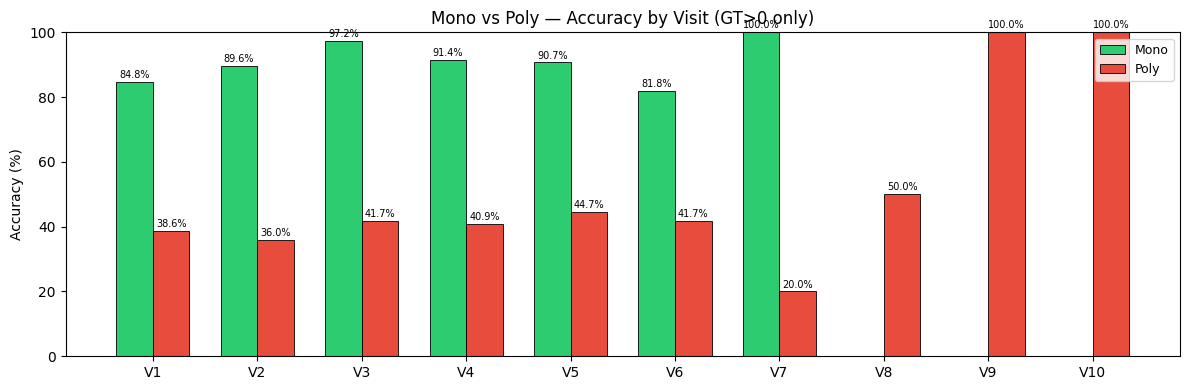

In [4]:
mp = (
    df_nonzero.groupby(['visit', 'mono_poly'])
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)

visits_present = sorted(df_nonzero['visit'].unique())
mono_acc = [mp[(mp['visit']==v) & (mp['mono_poly']=='mono')]['accuracy'].values[0]
            if len(mp[(mp['visit']==v) & (mp['mono_poly']=='mono')]) else np.nan
            for v in visits_present]
poly_acc = [mp[(mp['visit']==v) & (mp['mono_poly']=='poly')]['accuracy'].values[0]
            if len(mp[(mp['visit']==v) & (mp['mono_poly']=='poly')]) else np.nan
            for v in visits_present]

mp_pivot = mp.pivot(index='visit', columns='mono_poly', values='accuracy').reset_index()
mp_pivot['total'] = summary_nz.set_index('visit')['accuracy'].reindex(mp_pivot['visit']).values
print('Mono vs Poly Accuracy by Visit:')
print(mp_pivot.round(1).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(visits_present))
w = 0.35
bars_m = ax.bar(x - w/2, mono_acc, w, label='Mono', color='#2ecc71', edgecolor='black', linewidth=0.6)
bars_p = ax.bar(x + w/2, poly_acc, w, label='Poly', color='#e74c3c', edgecolor='black', linewidth=0.6)
for i in range(len(visits_present)):
    if not np.isnan(mono_acc[i]):
        ax.text(x[i]-w/2, mono_acc[i]+1.2, f'{mono_acc[i]:.1f}%', ha='center', fontsize=7)
    if not np.isnan(poly_acc[i]):
        ax.text(x[i]+w/2, poly_acc[i]+1.2, f'{poly_acc[i]:.1f}%', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([f'V{v}' for v in visits_present])
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Mono vs Poly — Accuracy by Visit (GT>0 only)')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

---
## V1/V2/V3 Focused Summary (direct comparison to CSV pipeline)

In [5]:
df3 = df_nonzero[df_nonzero['visit'].isin([1,2,3])].copy()

for v in [1,2,3]:
    sub = df3[df3['visit']==v]
    mono = sub[sub['mono_poly']=='mono']
    poly = sub[sub['mono_poly']=='poly']
    print(f'Visit {v}: overall={sub["match"].mean()*100:.1f}% (n={len(sub)})  '
          f'mono={mono["match"].mean()*100:.1f}% (n={len(mono)})  '
          f'poly={poly["match"].mean()*100:.1f}% (n={len(poly)})')

print(f'\nCSV pipeline reference (gptoss120b):')
print('  V1: 61.1% overall | V2: 71.1% | V3: 66.9% | All: 66.4%')

Visit 1: overall=71.0% (n=338)  mono=84.8% (n=237)  poly=38.6% (n=101)
Visit 2: overall=67.4% (n=362)  mono=89.6% (n=212)  poly=36.0% (n=150)
Visit 3: overall=71.4% (n=336)  mono=97.2% (n=180)  poly=41.7% (n=156)

CSV pipeline reference (gptoss120b):
  V1: 61.1% overall | V2: 71.1% | V3: 66.9% | All: 66.4%


---
## How Often is the Model Predicting Polytherapy?

In [6]:
def is_poly(cell):
    return len(cell.split('; ')) >= 2 if str(cell).strip() else False

for col in ['opt1','opt2','opt3']:
    df_nonzero[col+'_poly'] = df_nonzero[col].apply(is_poly)
df_nonzero['any_pred_poly'] = df_nonzero[['opt1_poly','opt2_poly','opt3_poly']].any(axis=1)

cross = (
    df_nonzero.groupby(['visit','mono_poly'])
    .agg(n=('any_pred_poly','count'), pred_poly=('any_pred_poly','sum'))
    .assign(pct=lambda x: (x['pred_poly']/x['n']*100).round(1))
    .reset_index()
)
print('% of visits where model predicted poly (any option) — by GT type and visit:')
print(cross.to_string(index=False))

% of visits where model predicted poly (any option) — by GT type and visit:
 visit mono_poly   n  pred_poly   pct
     1      mono 237         53  22.4
     1      poly 101         70  69.3
     2      mono 212        102  48.1
     2      poly 150        129  86.0
     3      mono 180         89  49.4
     3      poly 156        140  89.7
     4      mono 105         55  52.4
     4      poly 115        101  87.8
     5      mono  43         14  32.6
     5      poly  47         45  95.7
     6      mono  11          5  45.5
     6      poly  24         22  91.7
     7      mono   4          2  50.0
     7      poly  10          8  80.0
     8      poly   4          4 100.0
     9      poly   1          1 100.0
    10      poly   1          1 100.0


---
## GT Drug Count Distribution by Visit

In [7]:
def bucket(n):
    return '3+' if n >= 3 else str(n)

df['gt_bucket'] = df['gt_size'].apply(bucket)
bucket_order = ['0','1','2','3+']

dist = (
    df[df['visit'].isin([1,2,3])].groupby(['visit','gt_bucket'])
    .size().unstack(fill_value=0)
    .reindex(columns=bucket_order, fill_value=0)
)
dist['total'] = dist.sum(axis=1)
dist.index = dist.index.map({1:'Visit 1',2:'Visit 2',3:'Visit 3'})
print('GT drug count distribution (V1-V3):')
print(dist)

# Accuracy by gt_size bucket
acc_by_size = (
    df_nonzero.groupby('gt_size')
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)
print('\nAccuracy by GT drug count:')
print(acc_by_size.to_string(index=False))

GT drug count distribution (V1-V3):
gt_bucket   0    1    2  3+  total
visit                             
Visit 1    34  237   92   9    372
Visit 2     5  212  115  35    367
Visit 3     6  180  114  42    342

Accuracy by GT drug count:
 gt_size   n  correct  accuracy
       1 792      714 90.151515
       2 439      206 46.924829
       3 134       28 20.895522
       4  32        8 25.000000
       5   4        0  0.000000


---
## Which Option Matched? (Option 1 / 2 / 3)

In [8]:
matched = df_nonzero[df_nonzero['match']==True]
opt_dist = matched.groupby(['visit','matched_k']).size().unstack(fill_value=0)
opt_dist.index = [f'V{v}' for v in opt_dist.index]
opt_dist.columns = [f'Option {int(k)}' for k in opt_dist.columns]
print('Which option matched (correct predictions only):')
print(opt_dist)

Which option matched (correct predictions only):
     Option 1  Option 2  Option 3
V1        138        44        58
V2        173        39        32
V3        171        32        37
V4         94        23        26
V5         39         7        14
V6         12         3         4
V7          4         2         0
V8          2         0         0
V9          1         0         0
V10         1         0         0


---
## Visit Transitions V1→V2 and V2→V3 (GT mono/poly)

In [9]:
wide = df[['pid','visit','mono_poly']].pivot(index='pid', columns='visit', values='mono_poly')
wide.columns = [f'v{c}' for c in wide.columns]
wide = wide.replace('empty','no drug')

for pair, (a,b) in [('V1→V2',('v1','v2')),('V2→V3',('v2','v3')),('V3→V4',('v3','v4'))]:
    if a not in wide.columns or b not in wide.columns:
        continue
    sub = wide[[a,b]].dropna()
    sub['trans'] = sub[a] + ' → ' + sub[b]
    print(f'=== {pair} (n={len(sub)}) ===')
    print(sub['trans'].value_counts().to_string())
    print()

=== V1→V2 (n=367) ===
trans
mono → mono       180
poly → poly        97
mono → poly        49
no drug → mono     28
mono → no drug      5
poly → mono         4
no drug → poly      4

=== V2→V3 (n=342) ===
trans
mono → mono       174
poly → poly       135
mono → poly        20
mono → no drug      6
poly → mono         5
no drug → mono      1
no drug → poly      1

=== V3→V4 (n=234) ===
trans
poly → poly          105
mono → mono           99
mono → poly           10
mono → no drug         9
poly → mono            6
no drug → no drug      4
poly → no drug         1



---
## Filtering Analysis: Drop Weak/Empty Visits
Strategy 1: exclude empty GT (already done above)  
Strategy 2: also exclude visits where SeizureType = 'Not mentioned.' (model has no seizure type info)  
Strategy 3: only keep V1-V3 (comparable to CSV pipeline)

In [10]:
import json

reconc_path = os.path.join(HERE, 'pdf_reconc.json')
with open(reconc_path) as f:
    reconc = json.load(f)

# Build set of (pid, visit_num) where SeizureType is not mentioned
no_seizure_type = set()
for pid, visits in reconc.items():
    for vk, feats in visits.items():
        m = re.match(r'^Visit_(\d+)$', vk)
        if not m or not isinstance(feats, dict):
            continue
        vn = int(m.group(1))
        st_ans = feats.get('SeizureType', {}).get('Answer', '')
        if not st_ans or 'not mentioned' in st_ans.lower():
            no_seizure_type.add((pid, vn))

df_nonzero['has_seizure_type'] = ~df_nonzero.apply(lambda r: (r['pid'], r['visit']) in no_seizure_type, axis=1)
df_with_st = df_nonzero[df_nonzero['has_seizure_type']]

print('=== Filtering strategy comparison ===')
print(f'All visits (incl. empty GT):           {len(df):4d} rows, acc={df["match"].mean()*100:.1f}%')
print(f'GT > 0 drugs only:                     {len(df_nonzero):4d} rows, acc={df_nonzero["match"].mean()*100:.1f}%')
print(f'GT > 0 + has SeizureType:              {len(df_with_st):4d} rows, acc={df_with_st["match"].mean()*100:.1f}%')

df3_nz = df_nonzero[df_nonzero['visit'].isin([1,2,3])]
df3_st = df_with_st[df_with_st['visit'].isin([1,2,3])]
print(f'V1-V3 only, GT > 0:                   {len(df3_nz):4d} rows, acc={df3_nz["match"].mean()*100:.1f}%')
print(f'V1-V3 only, GT > 0 + has SeizureType: {len(df3_st):4d} rows, acc={df3_st["match"].mean()*100:.1f}%')
print(f'\nDropped by SeizureType filter: {len(df_nonzero) - len(df_with_st)} visits')

=== Filtering strategy comparison ===
All visits (incl. empty GT):           1486 rows, acc=64.3%
GT > 0 drugs only:                     1401 rows, acc=68.2%
GT > 0 + has SeizureType:              1195 rows, acc=66.8%
V1-V3 only, GT > 0:                   1036 rows, acc=69.9%
V1-V3 only, GT > 0 + has SeizureType:  887 rows, acc=68.5%

Dropped by SeizureType filter: 206 visits


Accuracy per visit (GT>0 + SeizureType present):
 visit   n  correct   accuracy
     1 299      214  71.571906
     2 305      199  65.245902
     3 283      195  68.904594
     4 188      121  64.361702
     5  75       49  65.333333
     6  30       15  50.000000
     7  10        2  20.000000
     8   3        1  33.333333
     9   1        1 100.000000
    10   1        1 100.000000


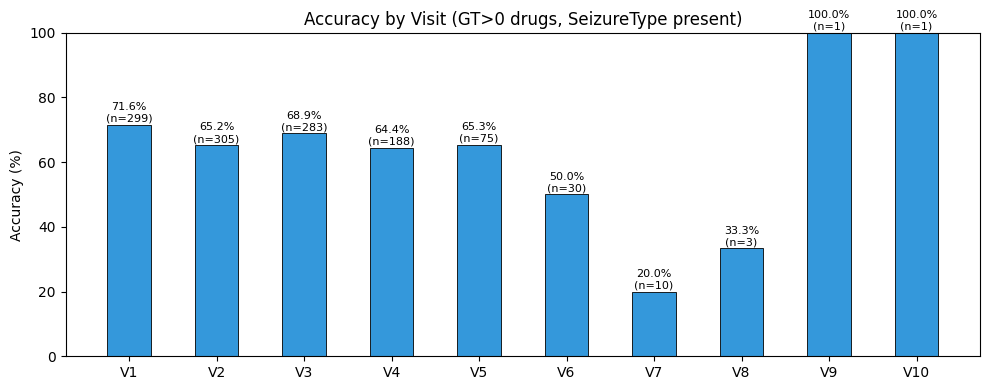

In [11]:
# Per-visit breakdown under best filter (GT>0 + has SeizureType)
summary_st = (
    df_with_st.groupby('visit')
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)
print('Accuracy per visit (GT>0 + SeizureType present):')
print(summary_st.to_string(index=False))

fig, ax = plt.subplots(figsize=(10,4))
vlabels = [f'V{v}' for v in summary_st['visit']]
bars = ax.bar(vlabels, summary_st['accuracy'], color='#3498db', edgecolor='black', linewidth=0.6, width=0.5)
for bar, row in zip(bars, summary_st.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{row.accuracy:.1f}%\n(n={row.n})', ha='center', fontsize=8)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 100)
ax.set_title('Accuracy by Visit (GT>0 drugs, SeizureType present)')
plt.tight_layout(); plt.show()

---
## Mono vs Poly — Filtered (GT>0 + SeizureType)

In [12]:
mp_st = (
    df_with_st.groupby(['visit','mono_poly'])
    .agg(n=('match','count'), correct=('match','sum'))
    .assign(accuracy=lambda x: x['correct']/x['n']*100)
    .reset_index()
)
print('Mono vs Poly accuracy (filtered):')
print(mp_st.pivot(index='visit', columns='mono_poly', values='accuracy').round(1).to_string())

# Summary table for V1/V2/V3 comparable to CSV pipeline
print('\n=== V1/V2/V3 Summary (filtered, GT>0 + SeizureType) ===')
for v in [1,2,3]:
    sub = df_with_st[df_with_st['visit']==v]
    if sub.empty: continue
    mono = sub[sub['mono_poly']=='mono']
    poly = sub[sub['mono_poly']=='poly']
    print(f'Visit {v}: overall={sub["match"].mean()*100:.1f}% (n={len(sub)})  '
          f'mono={mono["match"].mean()*100:.1f}% (n={len(mono)})  '
          f'poly={poly["match"].mean()*100:.1f}% (n={len(poly)})')

print(f'\nCSV pipeline reference (gptoss120b):')
print('  V1: 61.1% | mono: 72.4% | poly: 22.7%')
print('  V2: 71.1% | mono: 89.5% | poly: 30.8%')
print('  V3: 66.9% | mono: 93.0% | poly: 27.3%')

Mono vs Poly accuracy (filtered):
mono_poly   mono   poly
visit                  
1           85.7   38.2
2           88.4   34.8
3           97.2   39.6
4           91.3   38.5
5           91.4   42.5
6           77.8   38.1
7          100.0   11.1
8            NaN   33.3
9            NaN  100.0
10           NaN  100.0

=== V1/V2/V3 Summary (filtered, GT>0 + SeizureType) ===
Visit 1: overall=71.6% (n=299)  mono=85.7% (n=210)  poly=38.2% (n=89)
Visit 2: overall=65.2% (n=305)  mono=88.4% (n=173)  poly=34.8% (n=132)
Visit 3: overall=68.9% (n=283)  mono=97.2% (n=144)  poly=39.6% (n=139)

CSV pipeline reference (gptoss120b):
  V1: 61.1% | mono: 72.4% | poly: 22.7%
  V2: 71.1% | mono: 89.5% | poly: 30.8%
  V3: 66.9% | mono: 93.0% | poly: 27.3%
